In [46]:
import os
import sys

parentpath = os.path.dirname(os.getcwd())
sys.path.append(parentpath)
import pyrpl

FPGAsource = os.path.join(os.path.abspath(parentpath), 'pyrpl','fpga', 'red_pitaya.bin')
configfilename = 'config_LD_V1.yml'
CONFIGsource = os.path.join(os.path.abspath(os.getcwd()), 'configs', configfilename)

p = pyrpl.Pyrpl(config=CONFIGsource, filename=FPGAsource, gui = False)

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /home/EUD002691/Documents/pyrpl/MeasurementsV1/configs/config_LD_V1.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe config_LD_V1" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('config_LD_V1')
in a python terminal.


THIS IS TIMO!!!!


INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 172.16.20.41.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from pyrpl.async_utils import sleep

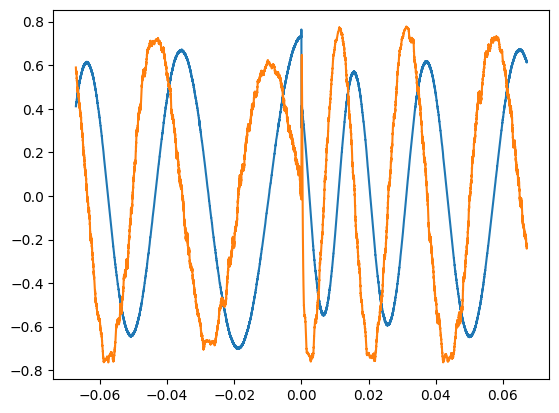

In [21]:
from pyrpl.async_utils import sleep

pid0 = p.rp.pid0
pid0.running = False
s = p.rp.scope
T = 0.1
s.duration = T #seconds

asg0 = p.rp.asg0


asg0.output_direct = "out2"


pid0.ival = 0
curve = s.single_async()
sleep(0.2)

#pid0.running = True



sleep(T) 
res = curve.result()

pid0.running = False
pid0.ival = 0

asg0.output_direct = "off"

for y in res: 
    plt.plot(s.times, y)

In [20]:
iq1 = p.rp.iq1
iq1.quadrature_factor = iq1.quadrature_factor * 2

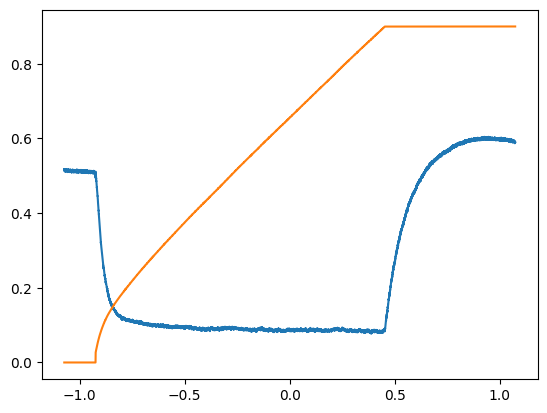

In [49]:
pid0 = p.rp.pid0
pid0.paused = True
s = p.rp.scope

T = 2.0 #seconds
s.duration = T 

#asg0 = p.rp.asg0

s.input2 = 'pid0' #############

pid0.ival = 0
curve = s.single_async()

sleep(T / 10)
pid0.paused = False
sleep(T) 

sleep(0.2)
res = curve.result()

pid0.paused = True
pid0.ival = 0


#asg0.output_direct = "off"

for y in res: 
    plt.plot(s.times, y)

s.input2 = 'iq1' ###################

In [44]:
pid0.p = 0.05
pid0.i = 1
print(pid0.p)
print(pid0.i)

0.050048828125
1.0005159917010866


In [9]:
print(s.input1) 
print(s.input2)

iq0
iq1


ERROR:pyrpl.redpitaya_client:Error occured in reading attempt 0. Reconnecting at addr 0x40100014 to _writes value [32768] by client 2


acq 0
acq 1
acq 1
acq 2
acq 2


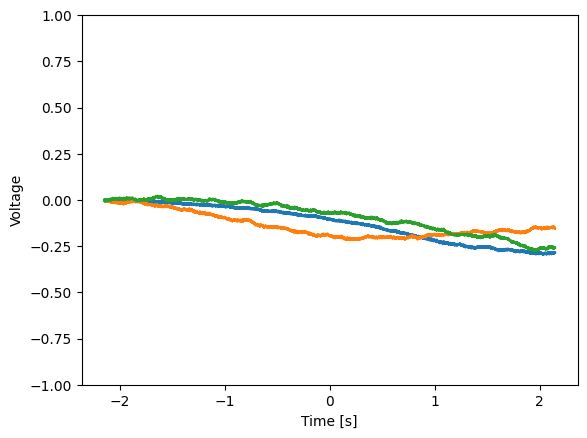

In [66]:
s = p.rp.scope

T = 3.0  # seconds
s.duration = T

# acquire N full traces and store channel 1 (zeroed at t=0)
N = 3
curves = []
times = []

for i in range(N):
    print('acq', i)
    """ 
    fut = s.single()
    # use pyrpl.async_utils.sleep so the event loop can run
    sleep(T + 0.2)
    res = fut.result()  # res is array([ch1, ch2])
    """ 
    res = s.single(timeout=None)  # blocking call
    ch1 = res[0] - res[0][0]  # remove DC offset
    curves.append(ch1)
    t = np.array(s.times)
    times.append(t + t[-1])  # shift time axis for each acquisition

# plot all acquired traces vs time
for ch in curves:
    plt.plot(s.times, ch)
plt.xlabel('Time [s]')
plt.ylabel('Voltage')
plt.ylim(-1, 1) 
plt.show()

In [58]:
for i in range(N):
    print('acq', i)

acq 0
acq 1
acq 2


Hieronder een eerste hele snelle poging tot het maken van een script dat lockt, stopt en meet! 

In [ ]:
import time
import pyrpl
from pyrpl.UMZI_lock import RPLockboxMZI

obj = RPLockboxMZI(gui=True, config_file='New-config-1-dec', yml_file='config_LD_V1.yml')

obj.calibrate(do_plot=True)
obj.start_locking()

s = obj.rp.scope
s.input1 = 'iq0' ######Do we still need to do this? 

count = 0 
while (count < 5): 
    if s.voltage_in1 < 0.01: 
        count += 1
    else: count = 0
        time.sleep(1)

obj.unlock()

#Now do your measurements!!! 



In [1]:
import os
parent_path = None
parent_path = os.path.abspath(parent_path) or os.path.dirname(os.getcwd())
parent_path

TypeError: expected str, bytes or os.PathLike object, not NoneType